In [ ]:
!pip install kaggle

In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"blossomspine","key":"9ab6979c60c7e62d7a3b8d19a212f189"}'}

In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d vuppalaadithyasairam/ultrasound-breast-images-for-breast-cancer -p ./data --unzip

Dataset URL: https://www.kaggle.com/datasets/vuppalaadithyasairam/ultrasound-breast-images-for-breast-cancer
License(s): CC0-1.0
 98% 553M/564M [00:07<00:00, 55.5MB/s]
100% 564M/564M [00:07<00:00, 84.2MB/s]


In [ ]:
import os
import shutil
import random

# Paths
DATASET_PATH = "/content/data/ultrasound breast classification/train"   # adjust if different
OUTPUT_PATH = "/content/data/ultrasound breast classification/train/train1"

# Classes in dataset
classes = ["benign","malignant"]

# Make sure output train folder exists
os.makedirs(OUTPUT_PATH, exist_ok=True)

# Process each class
for cls in classes:
    src_folder = os.path.join(DATASET_PATH, cls)
    dst_folder = os.path.join(OUTPUT_PATH, cls.replace(" ", "_"))  # replace spaces with underscore
    os.makedirs(dst_folder, exist_ok=True)

    # Get list of images
    images = [f for f in os.listdir(src_folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    # Shuffle to randomize
    random.shuffle(images)

    # Take images
    selected_images = images[:1500]

    # Copy to train folder
    for img in selected_images:
        shutil.copy(os.path.join(src_folder, img), os.path.join(dst_folder, img))

    print(f"{cls}: {len(selected_images)} images copied to {dst_folder}")

print(" Train dataset prepared successfully!")

benign: 1500 images copied to /content/data/ultrasound breast classification/train/train1/benign
malignant: 1500 images copied to /content/data/ultrasound breast classification/train/train1/malignant
 Train dataset prepared successfully!


In [ ]:
train_dir = "/content/data/ultrasound breast classification/train/train1"

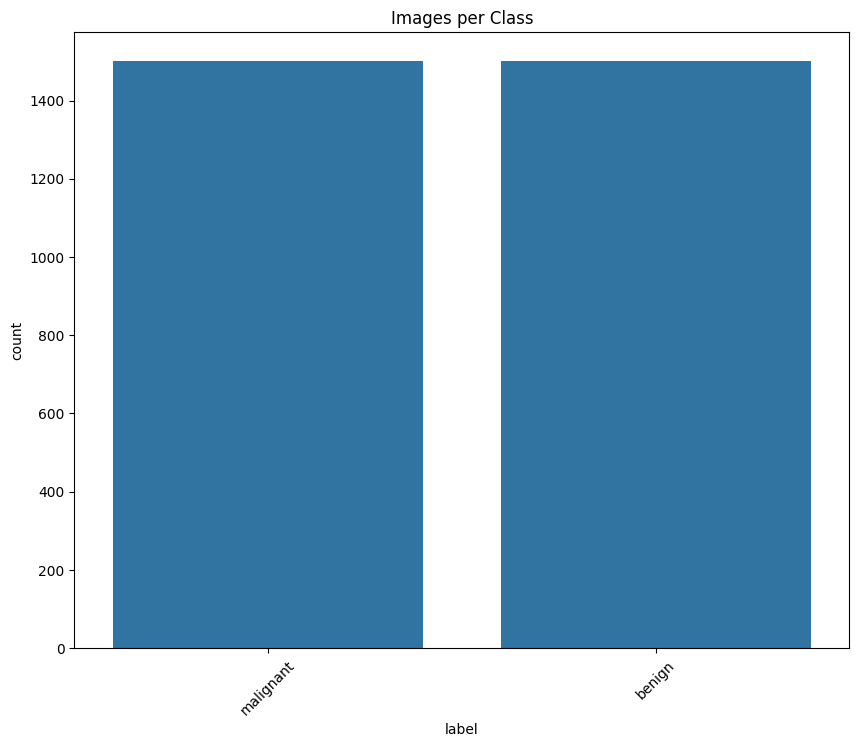

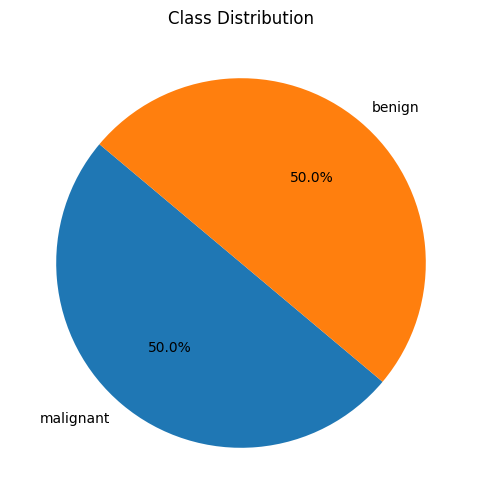

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Count images per class
df = pd.DataFrame([(cls, len(os.listdir(os.path.join(train_dir, cls))))
                   for cls in os.listdir(train_dir)], columns=["label", "count"])

# Bar chart
plt.figure(figsize=(10, 8))
sns.barplot(x="label", y="count", data=df)
plt.xticks(rotation=45)
plt.title("Images per Class")
plt.show()

# Pie chart
df.set_index("label")["count"].plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=140,
    figsize=(6, 6),
)
plt.title("Class Distribution")
plt.ylabel("")
plt.show()

In [ ]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split

# Build DataFrame with filepaths and labels
df_balanced = pd.DataFrame()
for i, cls in enumerate(os.listdir(train_dir)):
    cls_path = os.path.join(train_dir, cls)
    images = os.listdir(cls_path)
    df_cls = pd.DataFrame({
        "filepath": [os.path.join(cls_path, img) for img in images],
        "label": cls,
        "label_num": str(i)  # numeric label as string
    })
    df_balanced = pd.concat([df_balanced, df_cls], ignore_index=True)

# Train (80%), temp (20%)
train_df, temp_df = train_test_split(
    df_balanced,
    train_size=0.8,
    shuffle=True,
    stratify=df_balanced['label_num'],
    random_state=42
)

# Validation (10%), Test (10%)
valid_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    shuffle=True,
    stratify=temp_df['label_num'],
    random_state=42
)

# Check sizes
print("Train size:", train_df.shape)
print("Validation size:", valid_df.shape)
print("Test size:", test_df.shape)

# Class balance check
print("\nTrain class distribution:\n", train_df['label_num'].value_counts())
print("\nValidation class distribution:\n", valid_df['label_num'].value_counts())
print("\nTest class distribution:\n", test_df['label_num'].value_counts())

Train size: (2400, 3)
Validation size: (300, 3)
Test size: (300, 3)

Train class distribution:
 label_num
1    1200
0    1200
Name: count, dtype: int64

Validation class distribution:
 label_num
1    150
0    150
Name: count, dtype: int64

Test class distribution:
 label_num
1    150
0    150
Name: count, dtype: int64


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input

batch_size = 32
img_size = (224, 224)

tr_gen = ImageDataGenerator(
   preprocessing_function=preprocess_input,
    rotation_range=15,           # small rotations only
    width_shift_range=0.05,      # slight horizontal shifts
    height_shift_range=0.05,     # slight vertical shifts
    zoom_range=0.1,              # mild zoom
    horizontal_flip=True,        # flipping is okay for US images
    vertical_flip=False,         # usually vertical flip is not applied in US images
    shear_range=0.05,            # small shear
    fill_mode='nearest'          # fill empty pixels
    )

ts_gen = ImageDataGenerator(preprocessing_function=preprocess_input)


train_gen = tr_gen.flow_from_dataframe(train_df, x_col='filepath', y_col='label_num',
                                       target_size=img_size, class_mode='sparse',
                                       color_mode='rgb', shuffle=True, batch_size=batch_size)

valid_gen = ts_gen.flow_from_dataframe(valid_df, x_col='filepath', y_col='label_num',
                                       target_size=img_size, class_mode='sparse',
                                       color_mode='rgb', shuffle=True, batch_size=batch_size)

test_gen = ts_gen.flow_from_dataframe(test_df, x_col='filepath', y_col='label_num',
                                      target_size=img_size, class_mode='sparse',
                                      color_mode='rgb', shuffle=False, batch_size=batch_size)

Found 2400 validated image filenames belonging to 2 classes.
Found 300 validated image filenames belonging to 2 classes.
Found 300 validated image filenames belonging to 2 classes.


In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, Dropout, BatchNormalization,
    GlobalAveragePooling2D, Conv2D, Multiply, Concatenate, Lambda
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import backend as K

# Spatial Attention Block (CBAM-style)
def spatial_attention(input_tensor):
    # Average pooling across channels
    avg_pool = Lambda(lambda x: K.mean(x, axis=-1, keepdims=True))(input_tensor)
    # Max pooling across channels
    max_pool = Lambda(lambda x: K.max(x, axis=-1, keepdims=True))(input_tensor)
    # Concatenate along channel axis
    concat = Concatenate(axis=-1)([avg_pool, max_pool])
    # Convolution + sigmoid activation
    attention = Conv2D(1, kernel_size=7, padding='same', activation='sigmoid')(concat)
    # Multiply attention with input
    return Multiply()([input_tensor, attention])

# EfficientNet with Spatial Attention
def create_efficientnet_spatial(input_shape=(224,224,3), num_classes=3):
    inputs = Input(shape=input_shape)
    base = EfficientNetB0(weights='imagenet', include_top=False, input_tensor=inputs)

    # Freeze most layers (fine-tune last 10)
    for layer in base.layers[:-10]:
        layer.trainable = False

    x = base.output

    # Apply Spatial Attention
    x = spatial_attention(x)

    # Global pooling and dense layers
    x = GlobalAveragePooling2D()(x)
    x = Dense(512, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    return Model(inputs, outputs)

# Create and compile the model
model = create_efficientnet_spatial(num_classes=3)
model.compile(optimizer=Adam(0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Show summary
model.summary()


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,839,689 (18.46 MB)

 Trainable params: 1,682,326 (6.42 MB)

 Non-trainable params: 3,157,363 (12.04 MB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint , ReduceLROnPlateau

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint("best_model.h5", monitor='val_accuracy', save_best_only=True, verbose=1)
]

history = model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=20,
    callbacks= callbacks,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5453 - loss: 1.1460
Epoch 1: val_accuracy improved from -inf to 0.83333, saving model to best_model.h5


75/75 ━━━━━━━━━━━━━━━━━━━━ 261s 3s/step - accuracy: 0.5467 - loss: 1.1426 - val_accuracy: 0.8333 - val_loss: 0.7979 - learning_rate: 1.0000e-04
Epoch 2/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7787 - loss: 0.5633
Epoch 2: val_accuracy improved from 0.83333 to 0.84333, saving model to best_model.h5


75/75 ━━━━━━━━━━━━━━━━━━━━ 233s 3s/step - accuracy: 0.7788 - loss: 0.5630 - val_accuracy: 0.8433 - val_loss: 0.6110 - learning_rate: 1.0000e-04
Epoch 3/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8021 - loss: 0.4642
Epoch 3: val_accuracy did not improve from 0.84333
75/75 ━━━━━━━━━━━━━━━━━━━━ 248s 3s/step - accuracy: 0.8025 - loss: 0.4637 - val_accuracy: 0.8367 - val_loss: 0.4411 - learning_rate: 1.0000e-04
Epoch 4/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8665 - loss: 0.3383
Epoch 4: val_accuracy improved from 0.84333 to 0.87000, saving model to best_model.h5


75/75 ━━━━━━━━━━━━━━━━━━━━ 240s 3s/step - accuracy: 0.8664 - loss: 0.3384 - val_accuracy: 0.8700 - val_loss: 0.3269 - learning_rate: 1.0000e-04
Epoch 5/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8897 - loss: 0.3078
Epoch 5: val_accuracy improved from 0.87000 to 0.90333, saving model to best_model.h5


...

75/75 ━━━━━━━━━━━━━━━━━━━━ 237s 3s/step - accuracy: 0.9137 - loss: 0.2258 - val_accuracy: 0.9333 - val_loss: 0.1596 - learning_rate: 1.0000e-04
Epoch 10/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9362 - loss: 0.1649
Epoch 10: val_accuracy did not improve from 0.93333
75/75 ━━━━━━━━━━━━━━━━━━━━ 244s 3s/step - accuracy: 0.9361 - loss: 0.1650 - val_accuracy: 0.9267 - val_loss: 0.1718 - learning_rate: 1.0000e-04
Epoch 11/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9448 - loss: 0.1494
Epoch 11: val_accuracy improved from 0.93333 to 0.94000, saving model to best_model.h5


75/75 ━━━━━━━━━━━━━━━━━━━━ 234s 3s/step - accuracy: 0.9449 - loss: 0.1494 - val_accuracy: 0.9400 - val_loss: 0.1345 - learning_rate: 1.0000e-04
Epoch 12/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9386 - loss: 0.1497
Epoch 12: val_accuracy did not improve from 0.94000
75/75 ━━━━━━━━━━━━━━━━━━━━ 236s 3s/step - accuracy: 0.9386 - loss: 0.1495 - val_accuracy: 0.9333 - val_loss: 0.1580 - learning_rate: 1.0000e-04
Epoch 13/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9315 - loss: 0.1391
Epoch 13: val_accuracy improved from 0.94000 to 0.94667, saving model to best_model.h5


75/75 ━━━━━━━━━━━━━━━━━━━━ 248s 3s/step - accuracy: 0.9317 - loss: 0.1390 - val_accuracy: 0.9467 - val_loss: 0.1295 - learning_rate: 1.0000e-04
Epoch 14/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9330 - loss: 0.1642
Epoch 14: val_accuracy improved from 0.94667 to 0.96000, saving model to best_model.h5


75/75 ━━━━━━━━━━━━━━━━━━━━ 258s 3s/step - accuracy: 0.9331 - loss: 0.1637 - val_accuracy: 0.9600 - val_loss: 0.1077 - learning_rate: 1.0000e-04
Epoch 15/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9567 - loss: 0.1130
Epoch 15: val_accuracy did not improve from 0.96000
75/75 ━━━━━━━━━━━━━━━━━━━━ 235s 3s/step - accuracy: 0.9567 - loss: 0.1131 - val_accuracy: 0.9500 - val_loss: 0.1267 - learning_rate: 1.0000e-04
Epoch 16/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9612 - loss: 0.1166
Epoch 16: val_accuracy did not improve from 0.96000
75/75 ━━━━━━━━━━━━━━━━━━━━ 237s 3s/step - accuracy: 0.9612 - loss: 0.1165 - val_accuracy: 0.9600 - val_loss: 0.1246 - learning_rate: 1.0000e-04
Epoch 17/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9583 - loss: 0.1131
Epoch 17: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 17: val_accuracy did not improve from 0.96000
75/75 ━━━━━━━━━━━━━━━━━━━━ 237s 3s/step - accuracy: 0.9582 - loss: 0.1132 - val_ac

75/75 ━━━━━━━━━━━━━━━━━━━━ 237s 3s/step - accuracy: 0.9607 - loss: 0.0988 - val_accuracy: 0.9633 - val_loss: 0.0960 - learning_rate: 5.0000e-05
Restoring model weights from the end of the best epoch: 20.


In [ ]:
loss, accuracy = model.evaluate(test_gen, verbose=1)

print(f"Final Test Accuracy: {accuracy*100:.2f}%")
print(f"Final Test Loss: {loss:.4f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 28s 3s/step - accuracy: 0.9807 - loss: 0.0461
Final Test Accuracy: 97.67%
Final Test Loss: 0.0503


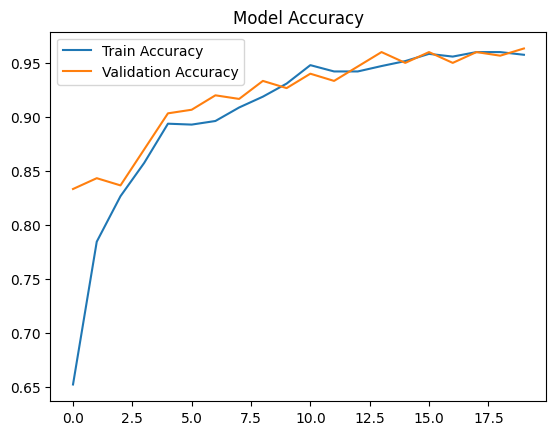

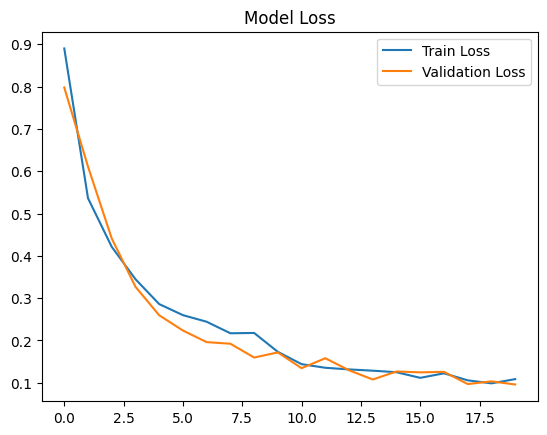

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Model Accuracy")
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Model Loss")
plt.show()

10/10 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       150
           1       0.98      0.97      0.98       150

    accuracy                           0.98       300
   macro avg       0.98      0.98      0.98       300
weighted avg       0.98      0.98      0.98       300



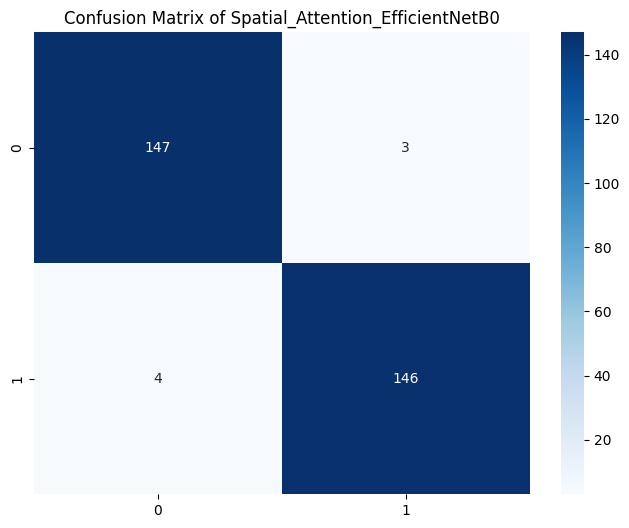

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# True labels from test generator
y_true = test_gen.classes

# Predictions
y_pred = np.argmax(model.predict(test_gen), axis=1) #argmax finds the index of the largest value in an array

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=list(test_gen.class_indices.keys())))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_gen.class_indices.keys(),
            yticklabels=test_gen.class_indices.keys())
plt.title("Confusion Matrix of Spatial_Attention_EfficientNetB0")
plt.show()